In [37]:
using Random
using LinearAlgebra
using Polynomials
using Plots

function generate_symmetric_matrix(l::Float64, r::Float64, n::Int)
    A = rand(n, n) .* (r - l) .+ l
    return (A + A') / 2
end

function danilevsky_algo(A::Matrix{Float64})
    n = size(A, 1)
    D  = copy(A)
    Bs = Matrix{Float64}(I, n, n)

    for i in n:-1:2
        d = D[i, i-1]
        r = copy(D[i, :])

        newrow = d .* D[i-1, :]
        for j in 1:n
            if j != i-1
                newrow .+= r[j] .* D[j, :]
            end
        end
        D[i-1, :] .= newrow

        col = copy(D[:, i-1])
        D[:, i-1] .= col ./ d
        for k in 1:n
            if k != i-1
                D[:, k] .-= (r[k] / d) .* col
            end
        end

        colB = copy(Bs[:, i-1])
        Bs[:, i-1] .= colB ./ d
        for k in 1:n
            if k != i-1
                Bs[:, k] .-= (r[k] / d) .* colB
            end
        end
    end
    return Bs, D
end

function characteristic_coeffs_from_frobenius(F::Matrix{Float64})
    v = -copy(F[1, :])
    return vcat(1.0, v)
end

companion_eigvec(λ, n) = [λ^(n-1-k) for k in 0:n-1]

function find_eigen_vectors(vals::Vector{Float64}, Bs::Matrix{Float64})
    n = size(Bs, 1)
    m = length(vals)
    X = Matrix{Float64}(undef, n, m)
    for j in 1:m
        y = companion_eigvec(vals[j], n)
        X[:, j] = Bs * y
        X[:, j] ./= norm(X[:, j])
    end
    return X
end

function check_orthogonal_cols(X; tol=1e-6)
    for i in 1:size(X,2)-1, j in i+1:size(X,2)
        s = dot(X[:, i], X[:, j])
        if abs(s) > tol
            println("Векторы i=$i и j=$j НЕ ортогональны")
            return false
        end
    end
    println("Собственные векторы ортогональны")
    return true
end

function gershgorin_intervals(A::Matrix{Float64})
    n = size(A, 1)
    intervals = Vector{Tuple{Float64,Float64}}()
    for i in 1:n
        r = sum(abs.(A[i, :])) - abs(A[i, i])
        c = A[i, i]
        push!(intervals, (c - r, c + r))
    end
    return intervals
end


function check_vieta(A::Matrix, vals::Vector)
    sum_eigs = sum(vals)
    sp = sum(diag(A))
    if abs(sum_eigs - sp) > 1e-6
        println("\nПроверка Виета: не выполняется")
    else
        println("\nПроверка Виета: выполняется")
    end
end

function check_gershorin(vals::Vector, intervals::Vector)
    minL = minimum(first.(intervals))
    maxR = maximum(last.(intervals))

    bad_vals = [v for v in vals if v < minL || v > maxR]
    if !isempty(bad_vals)
        println("Проверка Гершгорина: ошибка")
        for v in bad_vals
            println("  λ = ", v)
        end
    else
        println("Проверка Гершгорина: выполняется")
    end
end

function plot_gershgorin_characteristic(A::Matrix{Float64};
    num_points::Int=2000, margin::Float64=0.1, digits::Int=4)

    println("Матрица A =")
    display(A)

    # Данилевский → коэффициенты
    Bs, F = danilevsky_algo(A)
    coeffs = characteristic_coeffs_from_frobenius(F)

    println("\nФорма Фробениуса:"); display(F)
    println("\nКоэффициенты характеристического многочлена:")
    println(round.(coeffs; digits=digits))

    # Собственные значения/векторы
    λs = eigvals(Symmetric(A)) |> collect
    println("\nСобственные значения λ:"); println(round.(λs; digits=digits))
    vecs = find_eigen_vectors(real(λs), Bs)
    println("\nСобственные векторы (нормированные):")
    for j in 1:size(vecs, 2)
        println("v_$j = ", round.(vecs[:, j]; digits=digits))
    end
    println(); check_orthogonal_cols(vecs)

    ints = gershgorin_intervals(A)
    xmin = minimum(first.(ints)); xmax = maximum(last.(ints))
    total_interval = (xmin, xmax)

    println("\nИнтервалы Гершгорина:")
    for (k, (l, r)) in enumerate(ints)
        println("I$k = [", round(l; digits=digits), ", ", round(r; digits=digits), "]")
    end
    println("Общий интервал: [", round(xmin; digits=digits), ", ", round(xmax; digits=digits), "]")

    L = xmax - xmin; xmin -= margin*L; xmax += margin*L
    xs = range(xmin, xmax, length=num_points)
    ys = [poly_eval(coeffs, x) for x in xs]

    plt = plot(xs, ys, xlabel="λ", ylabel="p(λ)=det(λI - A)",
               label="p(λ)", title="Характеристический многочлен и интервалы Гершгорина")
    hline!([0.0], label="ось x", linestyle=:dot)

    for (k, (l, r)) in enumerate(ints)
        plot!([l, r], [0.0, 0.0], linewidth=5, label="I$k", alpha=0.9)
    end
    
    display(plt)
    return plt, λs, vecs, ints, total_interval
end

plot_gershgorin_characteristic (generic function with 1 method)

Матрица A =


5×5 Matrix{Float64}:
 -1.85709    1.00793     0.744609   0.989333  -0.511384
  1.00793   -1.08801    -0.108373   1.00771   -0.0388795
  0.744609  -0.108373    0.846029   0.652384  -0.299863
  0.989333   1.00771     0.652384   0.734952  -0.571393
 -0.511384  -0.0388795  -0.299863  -0.571393   0.0631513


Форма Фробениуса:


5×5 Matrix{Float64}:
 -1.30097      6.78139       6.63681      -3.56953  -0.624198
  1.0          0.0           0.0           0.0       0.0
  0.0          1.0           0.0           0.0      -5.55112e-17
  0.0          0.0           1.0           0.0       0.0
  1.10031e-16  2.07139e-16  -6.28428e-16   1.0      -1.52491e-16


Коэффициенты характеристического многочлена:
[1.0, 1.301, -6.7814, -6.6368, 3.5695, 0.6242]

Собственные значения λ:
[-2.7303, -1.33, -0.1427, 0.502, 2.3999]

Собственные векторы (нормированные):
v_1 = [0.8404, -0.4979, -0.1722, -0.043, 0.1196]
v_2 = [-0.4085, -0.7055, -0.0601, 0.5736, 0.0527]
v_3 = [0.0347, 0.2179, 0.1372, 0.2208, 0.9401]
v_4 = [-0.0664, -0.3546, 0.8404, -0.4006, 0.056]
v_5 = [-0.3482, -0.2848, -0.4916, -0.6782, 0.3099]

Собственные векторы ортогональны

Интервалы Гершгорина:
I1 = [-5.1104, 1.3962]
I2 = [-3.2509, 1.0749]
I3 = [-0.9592, 2.6513]
I4 = [-2.4859, 3.9558]
I5 = [-1.3584, 1.4847]
Общий интервал: [-5.1104, 3.9558]


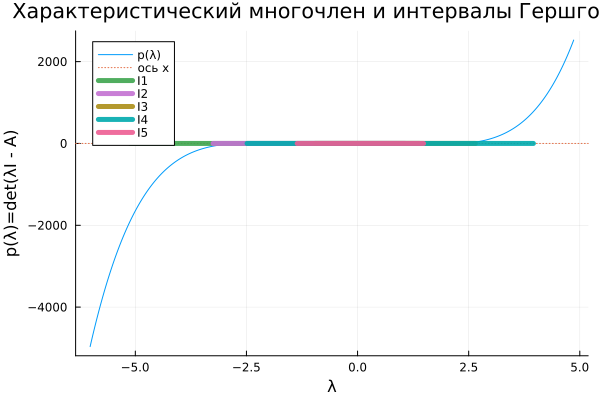

Собственные векторы ортогональны (в пределах допуска).

Проверка Виета: выполняется
Проверка Гершгорина: выполняется


In [40]:
n = 5
A = generate_symmetric_matrix(-2.0, 2.0, n)

plt, λs, vecs, ints, total_interval = plot_gershgorin_characteristic(A)
check_orthogonal(vecs)
check_vieta(A, λs)
check_gershorin(λs, ints)